
# *Gephyrocapsa huxleyi* Ecosystem Model

### Parameters:
| Symbol | Description |
|--------|-------------|
| **P** | *E. huxleyi* concentration (cells mL-1) |
| **B** | *Sulfitobacter* D7 (bacteria) concentration (cells mL-1) |
| **V** | Virus (EhV) concentration (particles mL-1) |
| **Z** | Zooplankton / ciliate concentration (cells mL-1) |
| **D** | Dead *E. huxleyi* cells (cells mL-1), lumped pool driving phi_B |
| **D_nat, D_bact, D_vir, D_zoop** | Dead *E. huxleyi* cells (cells mL-1), by pathway |
| **mu_P, mu_B** | Growth rates (day-1) |
| **k_P, k_B** | Carrying capacities |
| **phi_V** | Viral virulence (mL cell-1 day-1) |
| **beta_V** | Viral burst size |
| **rho** | Dead-cell scaling of bacterial phi_B (mL cell-1) |
| **Gmax, k_m** | Grazing parameters |
| **delta_P** | *E. hux* natural death rate (day-1) |
| **lambda_D** | Dead cell organic dissolution rate (day-1) |

This notebook covers the ecosystem-model experiment: the multi-mortality-pathway
model (natural death, bacterial lysis, viral lysis, grazing), the Latin-Hypercube
parameter sweep + clustering (Figure 5), and the grazing-inhibition-by-metabolites
variant kept as a labeled alternate branch.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
from scipy.stats.qmc import LatinHypercube, scale
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
import os

warnings.filterwarnings('ignore', category=RuntimeWarning)

colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']

In [11]:
# ODE paramters

params_eco = {
    'P0':       1.0000e+03, 'mu_P':     7.918218e-01, 'k_P':      5.382034e+06, 'delta_P':  5.294857e-02,
    'B0':       1.0000e+04, 'mu_B':     8.503184e-01, 'k_B':      1.022709e+08, 'beta_B':   3.384754e+00, 'rho':      5.113946e-15,
    'V0':       1.0000e+05, 'phi_V':    7.0737e-08, 'beta_V':   3.0701e+02,
    'Z0':       1.0000e+01, 'Gmax':     4.3600e-01, 'k_m':      1.7036e+01,
    'D0':       4.0000e+02, 'lambda_D': 3.409695e-01, 'theta_Z':  1.1400e-01
}

T_END_ECO   = 25.0
t_dense_eco = np.linspace(0, T_END_ECO, 600)


PARAM_ORDER_ECO = ['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'rho', 'lambda_D',
                    'beta_V', 'phi_V', 'Gmax', 'k_m', 'theta_Z']

# ODE
def ode_rhs_eco_base(t, y, params):
    P, D, B, V, Z, D_nat, D_bact, D_vir, D_zoop = np.maximum(y, 0.0)
    mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, \
        beta_V, phi_V, Gmax, k_m, theta_Z = params

    phi_B = rho * D
    graz  = Gmax * P / (k_m + P) * Z

    dPdt = mu_P * P * (1 - P / k_P) - delta_P * P - phi_B * P * B - phi_V * P * V - graz
    dDdt = delta_P * P + phi_B * P * B + phi_V * P * V - lambda_D * D
    dBdt = mu_B * B * (1 - B / k_B) + beta_B * phi_B * P * B
    dVdt = beta_V * phi_V * P * V
    dZdt = theta_Z * graz

    # death fractionation
    dD_nat  = delta_P * P    - lambda_D * D_nat
    dD_bact = phi_B * P * B  - lambda_D * D_bact
    dD_vir  = phi_V * P * V  - lambda_D * D_vir
    dD_zoop = graz           - lambda_D * D_zoop

    return [dPdt, dDdt, dBdt, dVdt, dZdt, dD_nat, dD_bact, dD_vir, dD_zoop]

# Solver
def run_ode_eco(p, t_out, rhs=ode_rhs_eco_base):
    params = [p[name] for name in PARAM_ORDER_ECO]
    y0 = [p['P0'], p['D0'], p['B0'], p['V0'], p['Z0'], p['D0'], 0.0, 0.0, 0.0]
    t_eval = np.unique(t_out)
    t_span = (0.0, float(t_eval.max()) + 0.1)
    for method in ('RK45', 'Radau'):
        try:
            sol = solve_ivp(rhs, t_span, y0, method=method, t_eval=t_eval,
                            args=(params,), rtol=1e-6, atol=1e-9)
            if sol.success and np.all(np.isfinite(sol.y)):
                interp = lambda row: np.interp(t_out, t_eval, row)
                return [np.maximum(interp(sol.y[i]), 1.0) for i in range(9)]
        except Exception:
            continue
    return None

In [12]:
# Latin hypercube sampler
N_SAMPLES = 5000
PARAM_RANGES = {
    'rho':    (1e-15, 5e-14),
    'phi_V':  (1e-10, 1e-7),
    'beta_V': (200,   800),
    'Gmax':   (0.4,   5),
    'k_m':    (4800,     48000),
}
PARAM_NAMES = list(PARAM_RANGES.keys())
N_PARAMS    = len(PARAM_NAMES)

sampler   = LatinHypercube(d=N_PARAMS, seed=42)
unit_cube = sampler.random(n=N_SAMPLES)
lo = [PARAM_RANGES[k][0] for k in PARAM_NAMES]
hi = [PARAM_RANGES[k][1] for k in PARAM_NAMES]
samples = scale(unit_cube, lo, hi)

results_sweep = []
params_sweep  = []
for row in samples:
    p = {**params_eco}
    for name, val in zip(PARAM_NAMES, row):
        p[name] = val
    res = run_ode_eco(p, t_dense_eco)
    results_sweep.append(res)
    params_sweep.append(p)

n_ok = sum(r is not None for r in results_sweep)
print(f'Completed {N_SAMPLES} runs -- {n_ok} succeeded, {N_SAMPLES - n_ok} failed.')

Completed 5000 runs -- 5000 succeeded, 0 failed.


In [13]:
# Clustering runs
N_CLUSTERS = 3

features  = []
valid_idx = []

for i, res in enumerate(results_sweep):
    if res is None: continue
    P_t, D_t, B_t, V_t, Z_t, D_nat, D_bact, D_vir, D_zoop = res
    p = params_sweep[i]
    phi_B_t = p['rho'] * D_t
    graz_t  = p['Gmax'] * P_t / (p['k_m'] + P_t) * Z_t
    flux_nat  = p['delta_P'] * P_t
    flux_bact = phi_B_t      * P_t * B_t
    flux_vir  = p['phi_V']   * P_t * V_t
    flux_zoop = p['theta_Z'] * graz_t
    total_sum = (np.sum(flux_nat) + np.sum(flux_bact) +
                 np.sum(flux_vir) + np.sum(flux_zoop) + 1e-30)

    frac_nat  = float(np.sum(flux_nat)  / total_sum)
    frac_bact = float(np.sum(flux_bact) / total_sum)
    frac_vir  = float(np.sum(flux_vir)  / total_sum)
    frac_zoop = float(np.sum(flux_zoop) / total_sum)

    features.append([frac_nat, frac_bact, frac_vir, frac_zoop])
    valid_idx.append(i)

features  = np.array(features)
valid_idx = np.array(valid_idx)

scaler      = StandardScaler()
feat_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
labels = kmeans.fit_predict(feat_scaled)

print('Clustering complete. Cluster sizes:')
for k in range(N_CLUSTERS):
    print(f'  Cluster {k}: {(labels == k).sum()} runs')


Clustering complete. Cluster sizes:
  Cluster 0: 4082 runs
  Cluster 1: 358 runs
  Cluster 2: 560 runs


In [54]:
# Selecting centroid of each cluster
frac_df = pd.DataFrame(features, columns=['Natural', 'Bacterial', 'Viral', 'Grazing'])
frac_df['cluster'] = labels

representatives = {}
for k in range(N_CLUSTERS):
    mask     = labels == k
    centroid = kmeans.cluster_centers_[k]
    dists    = np.linalg.norm(feat_scaled[mask] - centroid, axis=1)
    local_i  = np.argmin(dists)
    global_i = valid_idx[np.where(mask)[0][local_i]]
    representatives[k] = global_i

# -- Sort clusters by grazing fraction descending after k-means ---------------
cluster_means = frac_df.groupby('cluster').mean()
sort_order    = cluster_means['Grazing'].argsort()[::-1].values
# sort_order[0] = old cluster label that had highest grazing

label_map = {old: new for new, old in enumerate(sort_order)}

# Remap labels array and frac_df
labels            = np.array([label_map[l] for l in labels])
frac_df['cluster'] = labels

# Remap representatives dict
representatives = {label_map[old_k]: idx
                   for old_k, idx in representatives.items()}

print(frac_df.groupby('cluster').mean().round(3).to_string())

print('Cluster sizes after sorting:')
for k in range(N_CLUSTERS):
    print(f'  Cluster {k}: {(labels == k).sum()} runs')

for k in range(N_CLUSTERS):
    p = params_sweep[representatives[k]]
    print(f'Cluster {k}')
    print('\n'.join([f'  {n}={p[n]:.1e}' for n in PARAM_NAMES]))
    print()


         Natural  Bacterial  Viral  Grazing
cluster                                    
0          0.068      0.018  0.914      0.0
1          0.082      0.717  0.201      0.0
2          0.068      0.024  0.908      0.0
Cluster sizes after sorting:
  Cluster 0: 560 runs
  Cluster 1: 358 runs
  Cluster 2: 4082 runs
Cluster 0
  rho=1.4e-14
  phi_V=5.3e-08
  beta_V=3.2e+02
  Gmax=4.0e+00
  k_m=1.5e+04

Cluster 1
  rho=1.6e-14
  phi_V=2.4e-09
  beta_V=7.1e+02
  Gmax=3.6e+00
  k_m=2.4e+04

Cluster 2
  rho=2.1e-14
  phi_V=3.3e-08
  beta_V=4.9e+02
  Gmax=4.1e+00
  k_m=1.6e+04



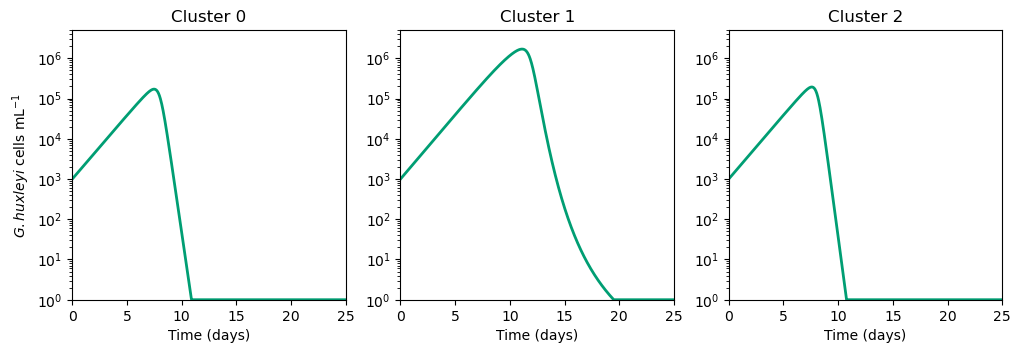

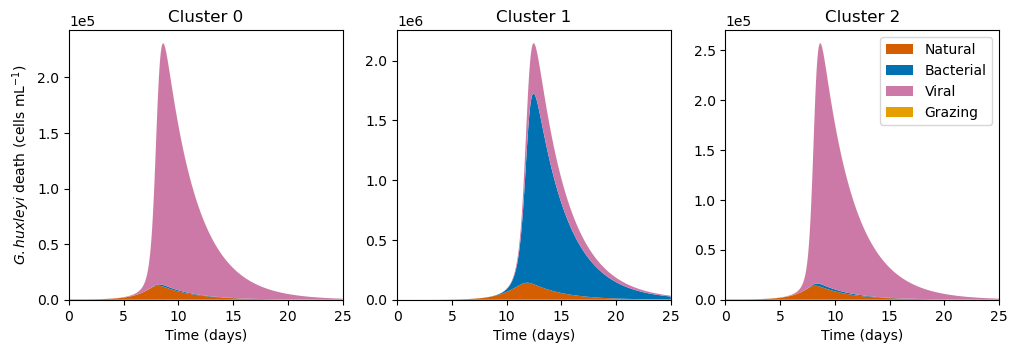

In [53]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.5))
for k in range(N_CLUSTERS):
    i   = representatives[k]
    res = results_sweep[i]
    p   = params_sweep[i]
    P_t, D_t, B_t, V_t, Z_t, D_nat, D_bact, D_vir, D_zoop = res
    ax[k].plot(t_dense_eco, P_t, color=colors[2], lw=2)
    ax[k].set_yscale('log')
    ax[k].set_xlabel('Time (days)')
    ax[k].set_xlim(0, T_END_ECO)
    ax[k].set_ylim(1, 5e6)
    ax[k].set_title(f'Cluster {k}')
ax[0].set_ylabel(r'$\it{G. huxleyi}$ cells mL$^{-1}$')

fig, ax = plt.subplots(1, 3, figsize=(12, 3.5))
for k in range(N_CLUSTERS):
    i   = representatives[k]
    res = results_sweep[i]
    p   = params_sweep[i]
    P_t, D_t, B_t, V_t, Z_t, D_nat, D_bact, D_vir, D_zoop = res
    ax[k].stackplot(
        t_dense_eco, D_nat, D_bact, D_vir, D_zoop,
        labels=['Natural', 'Bacterial', 'Viral', 'Grazing'],
        colors=[colors[5], colors[4], colors[6], colors[0]],
    )
    ax[k].set_xlabel('Time (days)')
    ax[k].set_xlim(0, T_END_ECO)
    # ax[k].set_ylim(0, 2.5e6)
    ax[k].ticklabel_format(style='sci', scilimits=(0, 0), axis='y')
    ax[k].set_title(f'Cluster {k}')
ax[0].set_ylabel(r'$\it{G. huxleyi}$ death (cells mL$^{-1}$)')
plt.legend(loc='best')